In [41]:
"""
Functions used to run the in-house algorithm to
incrementally compute the Delaunay triangulation

Created on Sun Nov  1 15:03:32 2020
Refactored : 30/07/2021

@author: jeremylhour
"""

import numpy as np
import itertools
import time
from numba import njit

from scipy.spatial.distance import cdist
from scipy.optimize import linprog
from cvxopt import matrix, solvers
import warnings

from scipy.spatial import Delaunay

solvers.options["show_progress"] = False
solvers.options["abstol"] = 1e-8
solvers.options["reltol"] = 1e-8
solvers.options["maxiters"] = 500


# ------------------------------------------------------------------------------
# UNIT FUNCTIONS
# ------------------------------------------------------------------------------
@njit
def get_ranks(node, nodes):
    """
    get_ranks:
        returns the ranks and anti-ranks of nodes by rank in closeness to node.

    Args:
        node (np.array): point for which we want to find the neighbors
        nodes (np.array): points that are candidate neighbors

    Returns:
        np.array: the ranks of nodes by rank in closeness to node.
        np.array: the anti-ranks of nodes by rank in closeness to node.
    """
    dist_ = np.sum((nodes - node) ** 2, axis=1)
    ranks = np.array([sorted(dist_).index(x) for x in dist_])
    return ranks, np.argsort(ranks)


def is_in_hull(x, points):
    """
    is_in_hull:
        test if x is in the convex hull of points.

    Args:
        x (np.array): the target point, of dimension p.
        points (np.array): the (m, p) array of the coordinates of m points in p dimensions that define the convex hull.

    Returns:
        bool: True if x is in the convex hull of points, False.
    """
    n = len(points)
    c = np.zeros(n)
    A = np.c_[points, np.ones(n)].T
    b = np.r_[x, 1.0]
    with warnings.catch_warnings():  # to ignore warning when degenerate cases
        warnings.simplefilter("ignore")
        lp = linprog(c, A_eq=A, b_eq=b)
    return lp.success


def compute_radius_and_barycenter(nodes, fix_overflow: bool = True):
    """
    compute_radius_and_barycenter:
        returns radius, coordinates of barycenter
        for circumscribed hypersphere for these points

    Note: normally, it should return np.sqrt(-a[0]/2), a[1:] @ nodes, but overflow can occur so I force a positive value inside sqrt.

    Source:
        https://math.stackexchange.com/questions/1087011/calculating-the-radius-of-the-circumscribed-sphere-of-an-arbitrary-tetrahedron

    Args:
        nodes (np.array): array of dimension (p+1) x p of the p+1 points in p dimension
        fix_overflow (bool): if True brutally fixes the overflow

    Returns:
        float: radius of the circumscribed hypersphere
        np.array: coordinates of the barycenter
    """
    p = nodes.shape[1]

    Delta = np.zeros((p + 2, p + 2))
    Delta[0,] = np.concatenate(([0], np.ones(p + 1)), axis=0)
    Delta[:, 0] = np.concatenate(([0], np.ones(p + 1)), axis=0)
    Delta[1:, 1:] = cdist(nodes, nodes) ** 2

    a = np.linalg.inv(Delta)[:, 0]
    if fix_overflow:
        return np.sqrt(np.abs(a[0]) / 2), a[1:] @ nodes
    else:
        return np.sqrt(-a[0] / 2), a[1:] @ nodes


@njit
def is_inside_sphere(nodes, barycenter, radius: float):
    """
    inside_ball:
        find if any of the nodes is inside the given sphere

    Args:
        nodes (np.array): points to check if inside
        barycenter (np.array): coordinates of the barycenter of the sphere
        radius (float): radius of the sphere.
    """
    dist_2 = np.diag((nodes - barycenter) @ (nodes - barycenter).T)
    return np.any(np.array([d < radius**2 for d in dist_2]))


@njit
def clip_to_zero(x, tol: float = 1e-5):
    """
    clip_to_zero:
        set values under threshold to zero.

    Args:
        x (np.array): numpy array of dimension 1.
        tol (float): tolerance.
    """
    x[x < tol] = 0.0
    return x / np.sum(x)


def find_knn(x, points, k: int = 1):
    """
    find_knn:
        find the k nearest neighbors of x node amongst points.

    Args:
        x (np.array): point for which we want to find the neighbors
        points (np.array): points that are candidate neighbors
        k (int): how many neighbors to return?

    Returns:
        np.array: the k nearest neighbors of x amongst points.
    """
    _, anti_ranks = get_ranks(x, points)
    return points[anti_ranks[:k],]


# ------------------------------------------------------------------------------
# MAIN FUNCTIONS
# ------------------------------------------------------------------------------
def incremental_pure_synth(X1, X0):
    """
    incremental_pure_synth:
        main algorithm, find the vertices of the simplex that X1 falls into
        returns the points and the antiranks

    Args:
        X1 (np.array): array of dimension p of the treated unit
        X0 (np.array): n x p array of untreated units

    """
    # get the ranks and anti-ranks of X0 with respect to their distances to X1
    _, anti_ranks = get_ranks(X1, X0)
    n0, p = X0.shape

    # Find the smallest set of points that contains X1,
    # by increasing the number of nearest neighbors until X1 is in the convex hull
    for j in range(p + 1, n0 + 1):
        X_NN = X0[anti_ranks[:j],]
        if is_in_hull(X1, X_NN):
            break

    # For all the subsets of cardinality p + 1 that have x in their convex hull
    #  check if a point in X0 is contained in the circumscribing hypersphere of any of these simplices
    #  (since previous simplices did not contain X1,
    #   we need only to consider the simplices that have the new nearest neighbors as a vertex)
    for k in range(j, n0 + 1):
        X_NN = X0[anti_ranks[:k],]
        for item in itertools.combinations(range(k - 1), p):
            candidate = item + (k - 1,)
            if is_in_hull(X1, X_NN[candidate,]):
                try:
                    radius, center = compute_radius_and_barycenter(
                        X_NN[candidate,]
                    )  # sometimes gives an error if points have the same values for a particular X0
                except:
                    radius = np.nan

                if (
                    np.isnan(radius)
                    or not is_inside_sphere(
                        np.delete(X0, anti_ranks[candidate,], 0), center, radius
                    )
                ):  # if the circumscribed hypersphere does not contain any other point, we stop
                    anti_ranks_tilde = sorted(anti_ranks[candidate,])
                    return X0[anti_ranks_tilde,], anti_ranks_tilde

    # when points is not inside convex hull, returns all the points
    anti_ranks_tilde = sorted(anti_ranks)
    return X0[anti_ranks_tilde,], anti_ranks_tilde


def pensynth_weights(X0, X1, pen: float = 0.0, V=None):
    """
    pensynth_weights:
        computes penalized synthetic control weights with penalty pen

    See "A Penalized Synthetic Control Estimator for Disaggregated Data"

    Args:
        X0 (np.array): n x p matrix of untreated units
        X1 (np.array): 1 x p matrix of the treated unit
        pen (float): lambda, positive tuning parameter
        V (np.array): weights for the norm
    """
    if V is None:
        V = np.identity(X0.shape[1])
    n0 = len(X0)

    # Objective function
    delta = np.diag((X0 - X1) @ V @ (X0 - X1).T)
    P = matrix(X0 @ V @ X0.T)
    q = matrix(-X0 @ V @ X1 + pen * delta / 2)

    # Adding up to one constraint
    A = matrix(1.0, (1, n0))
    b = matrix(1.0)

    # Non negativity constraints
    G = matrix(-np.identity(n0))
    h = matrix(np.zeros(n0))

    # Compute solution
    sol = solvers.qp(P, q, G, h, A, b)
    return clip_to_zero(np.squeeze(np.array(sol["x"])))


if __name__ == "__main__":
    # Test with simulated data
    n = 10
    p = 6

    X0 = np.random.normal(size=(n, p))
    X1 = X0.mean(axis=0)

    is_in_hull_flag = is_in_hull(X1, X0)
    if is_in_hull_flag:
        print("Treated is inside convex hull.")
    else:
        print("Treated not in convex hull.")

    print("=" * 80)
    print("Method 1 : Compute Delaunay Triangulation of X0")
    print("=" * 80)

    start_time = time.time()
    tri = Delaunay(X0)
    any_simplex = tri.find_simplex(X1)
    print(any_simplex >= 0)
    delaunay_simplex = tri.simplices[any_simplex]
    print(X0[sorted(delaunay_simplex),])
    print(f"Runtime : {(time.time() - start_time):.2f} sec")

    print("=" * 80)
    print("Method 2 : incremental algorithm")
    print("=" * 80)

    start_time = time.time()
    simplex, _ = incremental_pure_synth(X1=X1, X0=X0)
    print(simplex)
    print(f"Runtime : {(time.time() - start_time):.2f} sec")

Treated is inside convex hull.
Method 1 : Compute Delaunay Triangulation of X0
True
[[ 0.09911999  0.05553306 -1.29129761  0.08530084 -1.43301255  1.00970519]
 [ 0.61489828  0.27768693 -0.42646735  1.40629954 -1.2426957   0.33020724]
 [ 1.44747505  0.26864167  0.5560777  -0.22903183  0.40038227  0.68830416]
 [ 0.68494211  0.37000633 -1.55170058  0.62400782  1.03904561 -0.71041902]
 [ 0.52321387  0.92775474 -0.94069255 -1.07896905 -1.3044841   1.28225376]
 [ 0.39958586  0.20210957  1.34372582 -0.48031775  0.16221066 -0.42185883]
 [ 1.84292745  1.50374452  0.24617506  0.12462012  1.29271137  1.07253946]]
Runtime : 0.01 sec
Method 2 : incremental algorithm
[[ 0.09911999  0.05553306 -1.29129761  0.08530084 -1.43301255  1.00970519]
 [ 0.61489828  0.27768693 -0.42646735  1.40629954 -1.2426957   0.33020724]
 [ 1.44747505  0.26864167  0.5560777  -0.22903183  0.40038227  0.68830416]
 [ 0.68494211  0.37000633 -1.55170058  0.62400782  1.03904561 -0.71041902]
 [ 0.52321387  0.92775474 -0.94069255 

In [42]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Application to Lalonde (1986) dataset

Created on Sun Nov  1 10:51:38 2020

@author: jeremylhour
"""

import numpy as np
import pandas as pd
import time
from datetime import datetime
from tqdm import tqdm

In [43]:
if __name__ == "__main__":
    now = datetime.now()
    print(
        "This is a script to compute the pure synthetic control solution for Lalonde (1986) data.\n"
    )
    print(f"Launched on {now.strftime('%d, %b %Y, %H:%M:%S')} \n")
    print("Note : run downloadLalondeData.R script first.\n")

    print("=" * 80)
    print("DATA MANAGEMENT")
    print("=" * 80)

    DATA_PATH = "../data/"

This is a script to compute the pure synthetic control solution for Lalonde (1986) data.

Launched on 08, Apr 2026, 11:58:09 

Note : run downloadLalondeData.R script first.

DATA MANAGEMENT


In [44]:
path = '/Users/lucasdubois/Desktop/MASTERDATA/' 
df = pd.read_csv(path + "MASTER_FINAL.csv")
df = df.sort_values(["Country Name", "Year"])

In [45]:
inequality_variables = [
    "top10_inc",
    "top1_inc",
    "top10_w",
    "top1_w",
    "gini_disp",
    "gini_mkt",
    "gini_disp_se",
    "gini_mkt_se"
]

interaction_variables = [
    "log_rgdpe",
    "log_pop",
    "log_emp",
    "log_cn",
    "rgdpe_sq",
    "log_rgdpe_sq",
    "hc_ctfp",
    "labsh_irr",
    "cn_ctfp",
    "xr_irr",
    "csh_g_hc",
    "csh_c_hc",
    "rgdpe_ctfp",
    "pop_rgdpe",
    "delta_cn"
]

id_variables = ["Country Name", "Year"]

X = [
    col for col in df.columns
    if col not in inequality_variables + interaction_variables + id_variables
]

X = df[X].select_dtypes(include=["number"]).columns.tolist()

In [46]:
print(X)

['inflation', 'gdp_per_cap', 'unemployment', 'rgdpe', 'rgdpo', 'pop', 'emp', 'avh', 'hc', 'ccon', 'cda', 'cn', 'ck', 'ctfp', 'cwtfp', 'rgdpna', 'rtfpna', 'labsh', 'irr', 'delta', 'xr', 'csh_c', 'csh_g']


In [47]:
import numpy as np
import pandas as pd


def build_pensynth_matrices(
    df,
    unit_col,
    time_col,
    outcome_col,
    treatment_time,
    treated_unit=None,
    treat_col=None,
    covariate_cols=None,
    pre_outcome_lags=None,
    post_period=None,
    treated_value=1,
    control_value=0,
    drop_missing=True,
    standardize=True,
):
    """
    Build scaled and unscaled X/Y matrices for penalized SCM.
    """

    df = df.copy()

    if post_period is None:
        post_period = treatment_time

    covariate_cols = covariate_cols or []

    required_cols = [unit_col, time_col, outcome_col] + covariate_cols
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing columns in df: {missing_cols}")

    # Treatment definition
    if treated_unit is not None:
        df["_treated_internal_"] = (df[unit_col] == treated_unit).astype(int)
        treat_col_used = "_treated_internal_"
        treated_value = 1
        control_value = 0
    elif treat_col is not None:
        if treat_col not in df.columns:
            raise KeyError(f"Column not found: {treat_col}")
        treat_col_used = treat_col
    else:
        raise ValueError("Provide either treated_unit or treat_col.")

    unit_treat = df.groupby(unit_col)[treat_col_used].max()
    treated_units = unit_treat[unit_treat == treated_value].index.tolist()
    control_units = unit_treat[unit_treat == control_value].index.tolist()

    if len(treated_units) == 0:
        raise ValueError("No treated units found.")
    if len(control_units) == 0:
        raise ValueError("No control units found.")

    pre_df = df[df[time_col] < treatment_time].copy()
    post_df = df[df[time_col] == post_period].copy()

    if pre_df.empty:
        raise ValueError("No pre-treatment observations found.")
    if post_df.empty:
        raise ValueError(f"No observations found for post_period={post_period}.")

    X_parts = []
    predictor_names = []

    # Pre-treatment mean covariates
    if covariate_cols:
        pre_cov = (
            pre_df.groupby(unit_col)[covariate_cols]
            .mean()
            .rename(columns=lambda c: f"{c}_premean")
        )
        X_parts.append(pre_cov)
        predictor_names.extend(pre_cov.columns.tolist())

    # Pre-treatment outcome lags
    if pre_outcome_lags is not None:
        pre_times = sorted(pre_df[time_col].dropna().unique())

        if isinstance(pre_outcome_lags, int):
            if len(pre_times) < pre_outcome_lags:
                raise ValueError(
                    f"Requested {pre_outcome_lags} pre-treatment lags, "
                    f"but only {len(pre_times)} periods available."
                )
            chosen_times = pre_times[-pre_outcome_lags:]
        else:
            chosen_times = list(pre_outcome_lags)

        lag_wide = (
            pre_df[pre_df[time_col].isin(chosen_times)]
            .pivot(index=unit_col, columns=time_col, values=outcome_col)
            .sort_index(axis=1)
        )
        lag_wide.columns = [f"{outcome_col}_t{c}" for c in lag_wide.columns]
        X_parts.append(lag_wide)
        predictor_names.extend(lag_wide.columns.tolist())

    if not X_parts:
        raise ValueError("Provide at least covariate_cols and/or pre_outcome_lags.")

    X_unscaled_df = pd.concat(X_parts, axis=1)

    Y_df = (
        post_df[[unit_col, outcome_col]]
        .drop_duplicates(subset=[unit_col])
        .set_index(unit_col)
        .rename(columns={outcome_col: "Y_post"})
    )

    final_df = X_unscaled_df.join(Y_df, how="inner")

    if drop_missing:
        final_df = final_df.dropna()

    treated_final = [u for u in treated_units if u in final_df.index]
    control_final = [u for u in control_units if u in final_df.index]

    if len(treated_final) == 0:
        raise ValueError("No treated units left after filtering.")
    if len(control_final) == 0:
        raise ValueError("No control units left after filtering.")

    # Unscaled X
    X1_unscaled = final_df.loc[treated_final, predictor_names].to_numpy(dtype=float)
    X0_unscaled = final_df.loc[control_final, predictor_names].to_numpy(dtype=float)

    # Standardize using control-group moments only
    if standardize:
        mu = X0_unscaled.mean(axis=0)
        sigma = X0_unscaled.std(axis=0, ddof=0)
        sigma[sigma == 0] = 1.0

        X1 = (X1_unscaled - mu) / sigma
        X0 = (X0_unscaled - mu) / sigma
    else:
        X1 = X1_unscaled.copy()
        X0 = X0_unscaled.copy()

    Y1 = final_df.loc[treated_final, "Y_post"].to_numpy(dtype=float)
    Y0 = final_df.loc[control_final, "Y_post"].to_numpy(dtype=float)

    meta = {
        "treated_units": treated_final,
        "control_units": control_final,
        "predictor_names": predictor_names,
        "post_period": post_period,
        "treatment_time": treatment_time,
        "treated_unit_argument": treated_unit,
        "treat_col_used": treat_col_used,
        "X0_unscaled": X0_unscaled,
        "X1_unscaled": X1_unscaled,
        "standardized": standardize,
    }

    return X1, Y1, X0, Y0, meta

In [55]:
X1, Y1, X0, Y0, meta = build_pensynth_matrices(
    df=df,
    unit_col="Country Name",
    time_col="Year",
    outcome_col="top1_inc",
    treatment_time=1996,
    treated_unit="Brazil",
    covariate_cols=[
        "inflation", "rgdpe", "pop", "emp"
    ],
    pre_outcome_lags=10,
    post_period=1996
)

In [56]:

    ### Loading Lalonde's dataset rescaled as in the paper and unscaled for statistics
    X1_full = X1
    Y1_full = Y1
    X0_full = X0
    Y0_full = Y0

In [57]:
import numpy as np
import pandas as pd
import time
from tqdm import tqdm


def run_pensynth_analysis(
    X1,
    Y1,
    X0,
    Y0,
    meta=None,
    save_weights_path="pensynth_solution.parquet",
    save_stats_path="statistics.txt",
    penalty_outside_hull=1e-6,
):
    """
    Run Abadie-L'Hour penalized synthetic control on prepared matrices.

    Parameters
    ----------
    X1 : np.ndarray
        Predictors for treated units, shape (n_treated, p)
    Y1 : np.ndarray
        Outcomes for treated units, shape (n_treated,)
    X0 : np.ndarray
        Predictors for control units, shape (n_controls, p)
    Y0 : np.ndarray
        Outcomes for control units, shape (n_controls,)
    meta : dict or None
        Optional metadata returned by build_pensynth_matrices().
    save_weights_path : str
        File path to save weights as parquet.
    save_stats_path : str
        File path to save summary statistics.
    penalty_outside_hull : float
        Small penalty used when treated unit is outside convex hull.

    Returns
    -------
    results : dict
        Dictionary containing weights, counterfactuals, ATT, sparsity, etc.
    """

    print("=" * 80)
    print("COMPUTING PURE / PENALIZED SYNTHETIC CONTROL FOR EACH TREATED UNIT")
    print("=" * 80)

    n1 = X1.shape[0]
    n0 = X0.shape[0]
    p = X0.shape[1]

    allW = np.zeros((n1, n0))

    start_time = time.time()
    with tqdm(total=n1) as prog:
        for i, x in enumerate(X1):
            # Case 1: exact match among controls
            same_as_control = np.all(np.isclose(X0, x, atol=1e-10), axis=1)

            if np.any(same_as_control):
                control_idx = np.where(same_as_control)[0]
                allW[i, control_idx] = 1.0 / len(control_idx)

            else:
                # Case 2 / 3: inside or outside convex hull
                in_hull_flag = is_in_hull(x=x, points=X0)

                if in_hull_flag:
                    X0_tilde, antiranks = incremental_pure_synth(X1=x, X0=X0)
                    local_w = pensynth_weights(X0=X0_tilde, X1=x, pen=0.0)
                    allW[i, antiranks] = local_w
                else:
                    allW[i, :] = pensynth_weights(
                        X0=X0,
                        X1=x,
                        pen=penalty_outside_hull
                    )

            prog.update(1)

    elapsed = time.time() - start_time
    print(f"Time elapsed: {elapsed:.2f} sec")

    print("=" * 80)
    print("COMPUTING STATISTICS AND SAVING RESULTS")
    print("=" * 80)

    # Counterfactual outcomes for treated units
    Y0_hat = allW @ Y0

    # ATT
    att_i = Y1 - Y0_hat
    att = att_i.mean()

    print(f"ATT: {att:.6f}")

    # Predictor balance on the original X scale available here
    balance_check = (allW @ X0).mean(axis=0)

    predictor_names = None
    treated_units = None
    control_units = None

    if meta is not None:
        predictor_names = meta.get("predictor_names", None)
        treated_units = meta.get("treated_units", None)
        control_units = meta.get("control_units", None)

    if predictor_names is None:
        predictor_names = [f"X{k+1}" for k in range(p)]

    print("\nAverage synthetic-control predictor values:")
    for b, value in enumerate(balance_check):
        print(f"{predictor_names[b]}: {value:.6f}")

    # Sparsity
    sparsity_index = (allW > 0).sum(axis=1)
    print(f"\nMin sparsity: {sparsity_index.min():.0f}")
    print(f"Median sparsity: {np.median(sparsity_index):.0f}")
    print(f"Max sparsity: {sparsity_index.max():.0f}")

    active_index = ((allW > 0).sum(axis=0) > 0)
    print(f"Active control units: {active_index.sum():.0f}")

    # Theoretical p+1 benchmark
    high_sparsity = np.where(sparsity_index > (p + 1))[0]
    print(f"{len(high_sparsity)} treated units have sparsity larger than p+1 = {p+1}.")
    print(high_sparsity)

    # Save weights
    weights_df = pd.DataFrame(
        allW,
        index=treated_units if treated_units is not None else [f"Treated_{i+1}" for i in range(n1)],
        columns=control_units if control_units is not None else [f"Control_{j+1}" for j in range(n0)],
    )
    weights_df.to_parquet(save_weights_path, engine="pyarrow")

    # Optional treated-level results table
    treated_results = pd.DataFrame({
        "treated_unit": treated_units if treated_units is not None else [f"Treated_{i+1}" for i in range(n1)],
        "Y1_observed": Y1,
        "Y0_synthetic": Y0_hat,
        "treatment_effect": att_i,
        "sparsity": sparsity_index,
    })

    # Save stats
    with open(save_stats_path, "w") as f:
        f.write(f"ATT: {att:.6f}\n")
        f.write("\nAverage synthetic-control predictor values:\n")
        for b, value in enumerate(balance_check):
            f.write(f"{predictor_names[b]}: {value:.6f}\n")
        f.write(f"\nMin sparsity: {sparsity_index.min():.0f}\n")
        f.write(f"Median sparsity: {np.median(sparsity_index):.0f}\n")
        f.write(f"Max sparsity: {sparsity_index.max():.0f}\n")
        f.write(f"Active control units: {active_index.sum():.0f}\n")
        f.write(f"{len(high_sparsity)} treated units have sparsity larger than p+1 = {p+1}.\n")

    return {
        "weights": allW,
        "weights_df": weights_df,
        "treated_results": treated_results,
        "Y0_hat": Y0_hat,
        "att_i": att_i,
        "att": att,
        "balance_check": balance_check,
        "sparsity_index": sparsity_index,
        "active_index": active_index,
        "high_sparsity": high_sparsity,
        "meta": meta,
    }

In [58]:
results = run_pensynth_analysis(
    X1=X1,
    Y1=Y1,
    X0=X0,
    Y0=Y0,
    meta=meta,
    save_weights_path="brazil_pensynth_weights.parquet",
    save_stats_path="brazil_pensynth_statistics.txt"
)

COMPUTING PURE / PENALIZED SYNTHETIC CONTROL FOR EACH TREATED UNIT


100%|██████████| 1/1 [00:00<00:00, 55.24it/s]

Time elapsed: 0.02 sec
COMPUTING STATISTICS AND SAVING RESULTS
ATT: 0.006500

Average synthetic-control predictor values:
inflation_premean: 3.796345
rgdpe_premean: -0.332908
pop_premean: -0.350656
emp_premean: -0.349554
top1_inc_t1986: 0.891131
top1_inc_t1987: 0.918871
top1_inc_t1988: 0.939188
top1_inc_t1989: 0.970715
top1_inc_t1990: 0.994984
top1_inc_t1991: 1.023930
top1_inc_t1992: 1.057283
top1_inc_t1993: 1.057512
top1_inc_t1994: 1.103479
top1_inc_t1995: 1.115021

Min sparsity: 1
Median sparsity: 1
Max sparsity: 1
Active control units: 1
0 treated units have sparsity larger than p+1 = 15.
[]


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_scm_path(
    df,
    results,
    treated_unit="Brazil",
    unit_col="Country Name",
    time_col="year",
    outcome_col="etr",
    treatment_time=None,
    start_year=None,
    end_year=None,
):
    """
    Plot observed vs synthetic outcome over time for one treated unit.
    Uses donor weights from results["weights_df"].
    """

    weights_df = results["weights_df"]

    if treated_unit not in weights_df.index:
        raise ValueError(f"{treated_unit} not found in weights_df index.")

    # donor weights for treated unit
    w = weights_df.loc[treated_unit]
    w = w[w > 0]

    if w.empty:
        raise ValueError(f"No positive donor weights found for {treated_unit}.")

    # wide panel: rows=time, cols=units
    outcome_wide = (
        df.pivot(index=time_col, columns=unit_col, values=outcome_col)
        .sort_index()
    )

    # optionally restrict time range
    if start_year is not None:
        outcome_wide = outcome_wide[outcome_wide.index >= start_year]
    if end_year is not None:
        outcome_wide = outcome_wide[outcome_wide.index <= end_year]

    # keep only donor units موجود in data
    donor_units = [u for u in w.index if u in outcome_wide.columns]
    donor_weights = w.loc[donor_units].values
    donor_weights = donor_weights / donor_weights.sum()

    observed = outcome_wide[treated_unit]
    synthetic = outcome_wide[donor_units] @ donor_weights

    plot_df = pd.DataFrame({
        "Observed": observed,
        "Synthetic": synthetic
    }).dropna()

    # Main path plot
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df.index, plot_df["Observed"], marker="o", label="Observed")
    plt.plot(plot_df.index, plot_df["Synthetic"], marker="o", label="Synthetic")

    if treatment_time is not None:
        plt.axvline(treatment_time, linestyle="--", label="Treatment year")

    plt.xlabel("Year")
    plt.ylabel(outcome_col)
    plt.title(f"{treated_unit}: Observed vs Synthetic Over Time")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Gap plot
    plt.figure(figsize=(10, 6))
    gap = plot_df["Observed"] - plot_df["Synthetic"]
    plt.plot(plot_df.index, gap, marker="o", label="Gap")
    plt.axhline(0, linewidth=1)

    if treatment_time is not None:
        plt.axvline(treatment_time, linestyle="--", label="Treatment year")

    plt.xlabel("Year")
    plt.ylabel("Observed - Synthetic")
    plt.title(f"{treated_unit}: Gap Over Time")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return plot_df

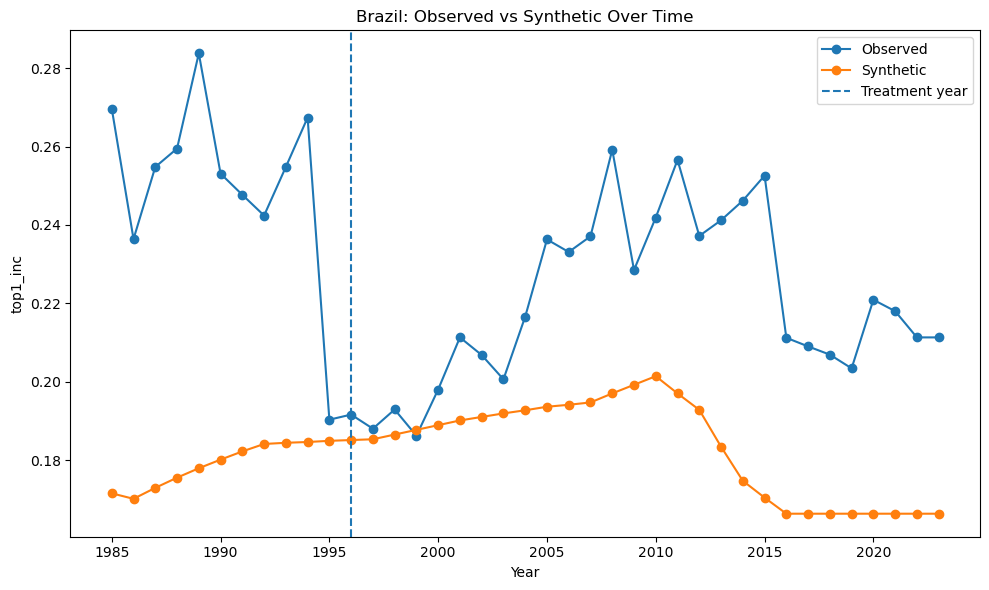

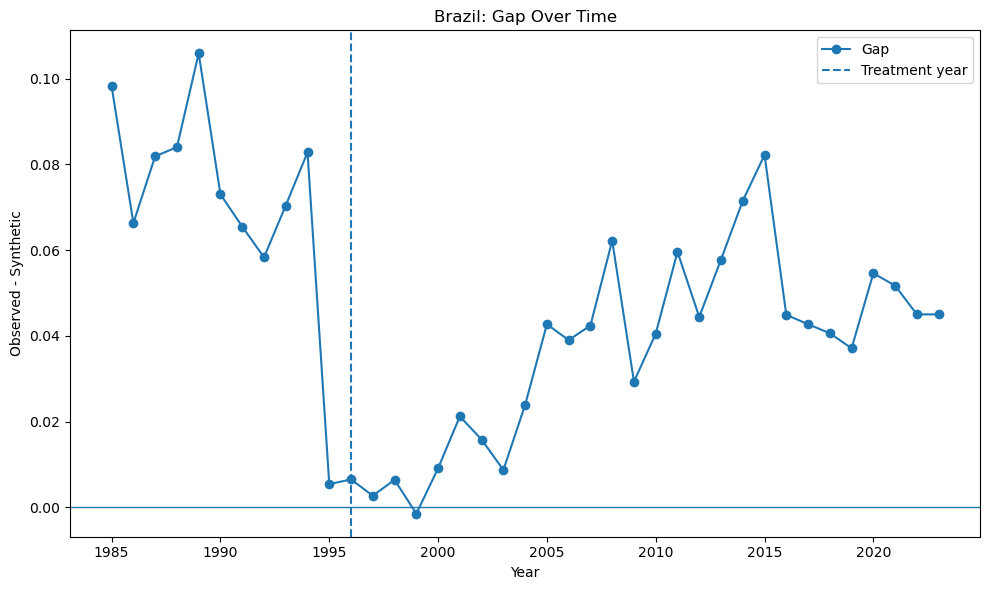

In [60]:
plot_df = plot_scm_path(
    df=df,
    results=results,
    treated_unit="Brazil",
    unit_col="Country Name",
    time_col="Year",
    outcome_col="top1_inc",
    treatment_time=1996
)

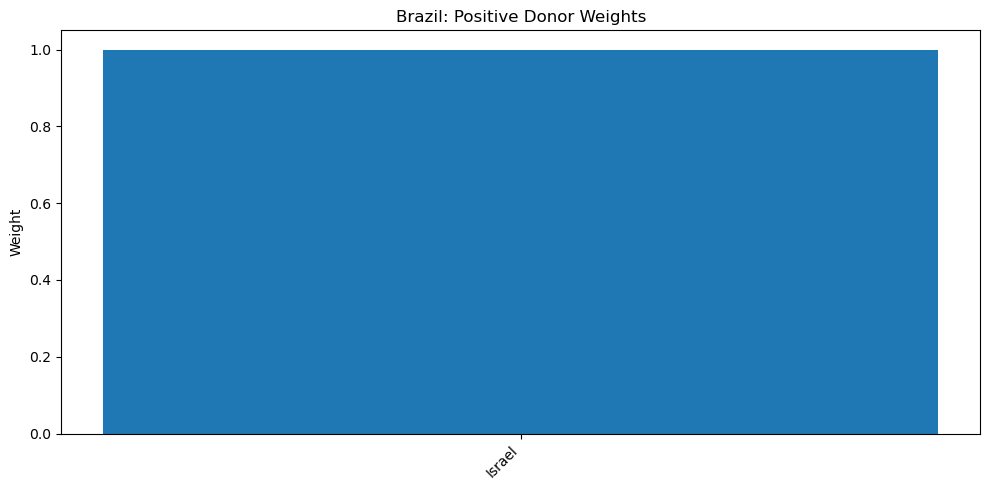

In [61]:
import matplotlib.pyplot as plt

w = results["weights_df"].loc["Brazil"]
w = w[w > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(w.index.astype(str), w.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Weight")
plt.title("Brazil: Positive Donor Weights")
plt.tight_layout()
plt.show()